<div align='center'>
<h1 style='font-size:38px;'>Using and creating phase functions</h1>
</div>

---


## 1. Imports and setup
We'll use the Image class which combines radiative transfer calculations with geometric disk models.

In [ ]:
from pyGrater.stargrains import Grain, Star
from pyGrater.image import Image
from pyGrater.density import two_power_law
from pyGrater.size_distributions import power_law_distribution
import matplotlib.pyplot as plt
import numpy as np


## 2. Define disk parameters
Set up the physical properties of the circumstellar disk including geometry, density profile, and grain size distribution.

In [5]:
# Disk geometry parameters
reference_radius = 60  # AU - reference radius for density profile
scale_height = 0.1 * reference_radius  # Scale height at reference radius

# Density profile parameters (two power-law)
inner_alpha = 10.0      # Inner power-law index
outer_alpha = -4.0      # Outer power-law index  
gamma_exponent = 2.0    # Vertical profile exponent
beta_exponent = 2.0     # Scale height flaring exponent

# Viewing geometry
inclination = 45.0      # Inclination angle (degrees)
position_angle = 90.0   # Position angle (degrees)  
longitude_of_node = 60.0 # Longitude of ascending node (degrees)

# Image parameters
num_pixels_x, num_pixels_y = 256, 256
pixel_size_au = 1   # Pixel size in AU
FOV_AU = num_pixels_x * pixel_size_au   
print(f"Disk extends from {reference_radius} AU with scale height {scale_height} AU")
print(f"Image size: {num_pixels_x}×{num_pixels_y} pixels at {pixel_size_au} AU/pixel")
print(f"Field of view: {num_pixels_x * pixel_size_au:.3f} × {num_pixels_y * pixel_size_au:.3f} AU")

Disk extends from 60 AU with scale height 6.0 AU
Image size: 256×256 pixels at 1 AU/pixel
Field of view: 256.000 × 256.000 AU


## 3. Grain size distribution parameters
Define the size distribution of dust grains in the disk.

In [6]:
# Size distribution parameters
grain_size_min = 0.01e-6    # Minimum grain size (meters)
grain_size_max = 3000e-6    # Maximum grain size (meters) 
size_power_index = 3.5      # Power-law index for size distribution
num_size_bins = 400         # Number of size bins for integration

size_params = {
    'a_min': grain_size_min,
    'a_max': grain_size_max, 
    'kappa': size_power_index,
    'N_sizes_integral': num_size_bins
}

print(f"Grain sizes: {grain_size_min*1e6:.2f} - {grain_size_max*1e6:.0f} µm")
print(f"Size distribution: power-law with index {size_power_index}")

Grain sizes: 0.01 - 3000 µm
Size distribution: power-law with index 3.5


## 4. Initialize grain and star objects
Load the optical properties and stellar spectrum needed for flux calculations.

In [7]:
# Create grain and star objects
grain = Grain(redo_Q=False, composition='astroSi')  # Load precomputed optical efficiencies
star = Star(star_name='HD113766')          # Load β Pictoris stellar properties and spectrum

print(f"Grain composition: {grain.grain_composition_name}")
print(f"Sublimation temperature: {grain.Tsub} K")
print(f"Star: {star.star_name}, Teff = {star.temp} K, Distance = {star.distance} pc")

CREATING GRAIN OBJECT
Developper parameters file: /Users/prioletp/PhD/public_codes/pyGrater/pyGrater/parameters/developper_params.yaml
Grain composition: astroSi
astroSi optical tables already exist :
--> Wavelengths : 1000 values from 5.0e-02 to 2.0e+03 microns
--> Sizes : 600 values from 1.0e-02 to 3.0e+03 microns
CREATING STAR OBJECT
Star properties file: /Users/prioletp/PhD/public_codes/pyGrater/data/star_data/stars_main_properties.txt
Star name: 'HD113766'
The temperature is 6650.0 K
The logg is 4.02 cgs
The radius is 1.35 R_sun
The distance is 108.63 pc
The spectral type is F5
The normalization band is V
The apparent magnitude in V band is 8.08 mag
The stellar spectrum is binned by a factor of 20
The closest spectrum in the grid has T_eff = 6600.0 K and log(g) = 4.0 cgs
Normalizing in the full spectrum
Stellar spectrum loaded from 0.0199698417077793 to 3917.5988438313925 µm and normalized.
Normalized in V-band to 8.08 mag
The stellar luminosity is 5.69 m2 L_sun
Grain composition:

## 5. Select wavelengths for imaging


In [14]:
wavelengths_for_calc = np.array([1.65])

## 6. Create Image objects with two different phase functions


### Import phase functions



In [15]:
from pyGrater.phase_functions import isotropic
from pyGrater.phase_functions import HenveyGreenstein


### Isotropic


In [17]:
# Initialize the Image object
img_obj = Image(grain, star, two_power_law, power_law_distribution, isotropic,
               wavelengths_for_calc)

# Combine all parameters for image calculation
image_params = {
    'r0': reference_radius,
    'alphain': inner_alpha, 
    'alphaout': outer_alpha,
    'h0': scale_height,
    'beta': beta_exponent,
    'gamma': gamma_exponent,
    'itilt': inclination,
    'PA': position_angle, 
    'omega': longitude_of_node,
    'nx': num_pixels_x,
    'ny': num_pixels_y,
    'FOV_AU': FOV_AU,
    'M_tot': 1e-7,  # Total dust mass in solar masses
    **size_params  # Add size distribution parameters
}

image_isotropic = img_obj.get_image(**image_params)
print(f"Generated image cube: {image_isotropic.shape}")

CREATING STAR-GRAIN OBJECT for the grain temperature calculations.
Loading the thermal distance array from file: temperatures_astroSi_Tsub1500.0_starHD113766.npz
Generated image cube: (1, 256, 256)


### Henvey-Greenstein

In [18]:
# Initialize the Image object
img_obj_hg = Image(grain, star, two_power_law, power_law_distribution, HenveyGreenstein,
               wavelengths_for_calc)

# Combine all parameters for image calculation
image_hg_params = {
    'r0': reference_radius,
    'alphain': inner_alpha, 
    'alphaout': outer_alpha,
    'h0': scale_height,
    'beta': beta_exponent,
    'gamma': gamma_exponent,
    'itilt': inclination,
    'PA': position_angle, 
    'omega': longitude_of_node,
    'nx': num_pixels_x,
    'ny': num_pixels_y,
    'FOV_AU': FOV_AU,
    'M_tot': 1e-7,  # Total dust mass in solar masses
    'g': 0.5,  # Asymmetry parameter for Henvey-Greenstein phase function
    **size_params  # Add size distribution parameters
}

print("Computing multi-wavelength disk images...")
image_hg = img_obj_hg.get_image(**image_hg_params)
print(f"Generated image cube: {image_hg.shape}")

CREATING STAR-GRAIN OBJECT for the grain temperature calculations.
Loading the thermal distance array from file: temperatures_astroSi_Tsub1500.0_starHD113766.npz
Computing multi-wavelength disk images...
Generated image cube: (1, 256, 256)


### Plottting

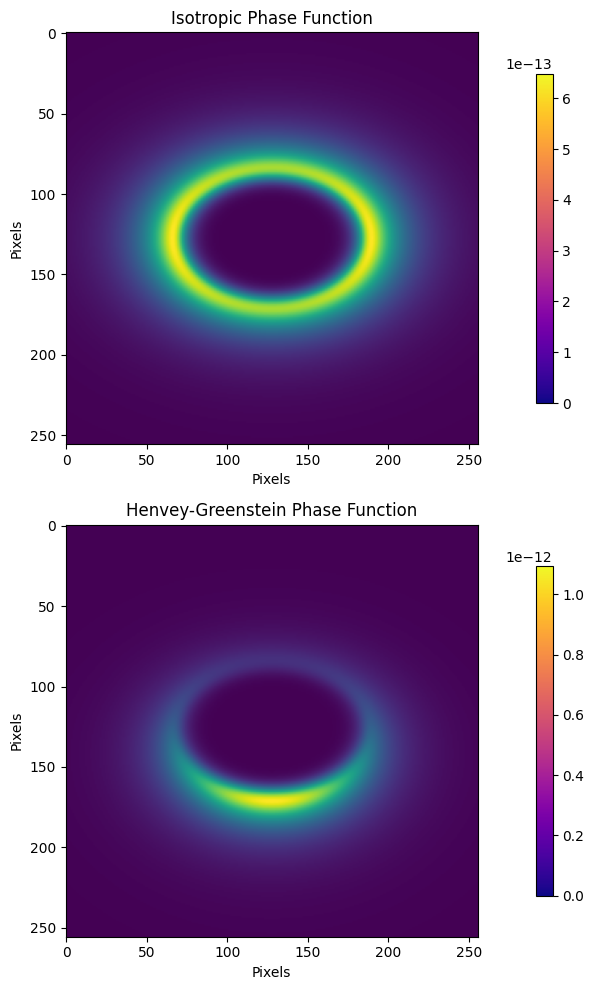

In [21]:
# Plot individual wavelengths with detailed analysis
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
axes = axes.flatten()

# Select interesting wavelengths
imgs = [image_isotropic, image_hg]
titles = ['Isotropic Phase Function', 'Henvey-Greenstein Phase Function']
for i in range(2):
    im = axes[i].imshow(imgs[i][0,:,:], cmap='plasma')
    axes[i].set_title(f'{wavelengths_for_calc[0]:.3f} µm')
    
    axes[i].imshow(imgs[i][0,:,:])
    
    plt.colorbar(im, ax=axes[i], shrink=0.8)
    axes[i].set_xlabel('Pixels')
    axes[i].set_ylabel('Pixels')
    axes[i].set_title(titles[i])

# plt.suptitle('Detailed View: Selected Wavelengths', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Create your own phase functions
In the phase_functions.py script, add a function that returns the phase function (normalized to 1) with the following form:

In [ ]:
def phase_function(phi, **kwargs):
    """
    Placeholder for a custom phase function.
    
    Parameters:
    - phi: Scattering angle in degrees (array-like)
    - kwargs: Additional parameters for the phase function
    
    Returns:
    - Phase function value at the given scattering angle
    """
    return phase_function_values

Then the parameters **kwargs must be passed when creating the image:

In [ ]:
img_obj.get_image(**kwargs)